# Computer Exercise 1.1 — Problem 11

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 1.1 Introduction — *Loss of Significance (rationalization)*
> **풀이 일자**: Day 04
> **언어**: Python 3 (NumPy / Matplotlib)


## 1. 문제 (원문)

> **11.** Investigate the computation of
> $$h(x) \;=\; \sqrt{x^{2}+1} \;-\; x$$
> for large positive $x$ (say $x = 10, 10^{2}, 10^{3}, \ldots, 10^{8}$). Show that the naive
> evaluation suffers from a loss of significance, and demonstrate that the
> mathematically equivalent rewriting
> $$\tilde{h}(x) \;=\; \frac{1}{\sqrt{x^{2}+1} + x}$$
> (obtained by multiplying numerator and denominator by the conjugate
> $\sqrt{x^{2}+1} + x$) recovers full precision. Compare the two by
> tabulating values, errors, and the number of correct digits.

### 한국어 풀이용 정리
$x$ 가 클 때 $\sqrt{x^2+1} \approx x + \frac{1}{2x}$ 이므로 $h(x)$ 는 *거의 같은 두 큰 수의 차*가 된다.
$x = 10^k$ 이면

$$
h(x) \approx \tfrac{1}{2x} = 5 \times 10^{-(k+1)}
$$

이 정도로 작은 값을 두 큰 수의 차로 만들면 자릿수가 사라진다.
**유리화(rationalization)** 공액 곱으로

$$
\sqrt{x^2+1} - x \;=\; \frac{(\sqrt{x^2+1}-x)(\sqrt{x^2+1}+x)}{\sqrt{x^2+1}+x} \;=\; \frac{1}{\sqrt{x^2+1}+x}
$$

분자가 *합* 으로 바뀌어 cancellation이 사라진다.


## 2. 수학적 배경

### 2.1 점근 전개로 본 참값
$x \gg 1$ 에서

$$
\sqrt{x^2+1} = x\sqrt{1+\tfrac{1}{x^2}} = x\!\left(1 + \tfrac{1}{2x^2} - \tfrac{1}{8x^4} + \mathcal{O}(x^{-6})\right)
$$

이므로

$$
\sqrt{x^2+1} - x = \tfrac{1}{2x} - \tfrac{1}{8x^3} + \mathcal{O}(x^{-5}).
$$

따라서 $h(x) \to 0$ 의 속도는 $\sim 1/(2x)$.

### 2.2 cancellation 분석
배정밀도에서 두 양수의 차 $a - b$ 의 상대오차는 대략

$$
\frac{|\,(a-b)_{\rm fl} - (a-b)\,|}{|a-b|} \;\approx\; \varepsilon_{\rm mach}\cdot\frac{|a|+|b|}{|a-b|}.
$$

$a = \sqrt{x^2+1}$, $b = x$ 이면 $|a|+|b| \approx 2x$, $|a-b| \approx 1/(2x)$, 따라서 증폭배율은 $\sim 4x^2$.
즉 $x = 10^k$ 일 때 약 $4 \times 10^{2k}$ 배의 상대오차 증폭. $x = 10^8$ 이면 $4 \times 10^{16} \cdot \varepsilon_{\rm mach} \sim 1$ — **모든 자릿수 소실**.

### 2.3 안정한 재작성 (유리화)
공액을 곱해서

$$
\boxed{\; \tilde h(x) \;=\; \frac{1}{\sqrt{x^2+1}+x} \;}
$$

분자가 합($\sqrt{x^2+1}+x \approx 2x$)이므로 cancellation 없이 안정적으로 평가된다.

### 2.4 정확 자릿수
참값 $h_{\rm ref}$ 와 비교하여 *correct decimal digits* 를

$$
d(x) = -\log_{10}\!\left(\frac{|h_{\rm computed} - h_{\rm ref}|}{|h_{\rm ref}|}\right)
$$

로 정의한다. 배정밀도 기준 최대값은 약 $-\log_{10}(\varepsilon_{\rm mach}) \approx 15.95$.


## 3. 풀이 흐름

1. $x = 10^k$ for $k = 1, 2, \ldots, 12$ 평가점.
2. **참값(reference)**: 점근 전개 또는 `np.float128`/`fractions` 도움 없이도 — 안정 식 자체를 reference로 사용하는 것이 가장 합리적. (별도로 `mpmath` 등이 있다면 더 좋지만 의존성을 늘리지 않기 위해 stable form을 신뢰).
3. **불안정** 평가: `sqrt(x*x + 1.0) - x` 직접 계산.
4. **안정** 평가: `1.0 / (sqrt(x*x + 1.0) + x)`.
5. 절대/상대오차, 정확 자릿수 표 작성.
6. 시각화: $\log x$ vs (a) 두 식의 값, (b) 상대오차, (c) 정확 자릿수.
7. **결과 해석**: cancellation 증폭배율이 이론적으로 $\sim 4x^2$ 임을 그래프와 비교.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ks = np.arange(1, 13)         # x = 10, 100, ..., 1e12
x  = 10.0 ** ks

# 불안정 (직접 차)
h_naive  = np.sqrt(x*x + 1.0) - x

# 안정 (유리화)
h_stable = 1.0 / (np.sqrt(x*x + 1.0) + x)

# 참값으로 안정 식 채택
h_ref = h_stable.copy()

# 점근 전개 비교용 (1/(2x) - 1/(8x^3))
h_asym = 1.0/(2.0*x) - 1.0/(8.0*x**3)

abs_err_naive = np.abs(h_naive - h_ref)
rel_err_naive = abs_err_naive / np.abs(h_ref)

# 0이 되었을 때 자릿수는 0으로 강제
with np.errstate(divide="ignore"):
    correct_digits = np.where(rel_err_naive > 0, -np.log10(rel_err_naive + 1e-30), 16.0)
    correct_digits = np.clip(correct_digits, 0.0, 16.0)

df = pd.DataFrame({
    "k": ks,
    "x = 10^k": x,
    "h_naive = sqrt(x^2+1) - x": h_naive,
    "h_stable = 1/(sqrt(x^2+1)+x)": h_stable,
    "asymptotic 1/(2x) - 1/(8x^3)": h_asym,
    "rel err of naive": rel_err_naive,
    "correct digits (naive)": correct_digits,
})
pd.set_option("display.float_format", lambda v: f"{v:.6e}")
df


,k,x = 10^k,h_naive = sqrt(x^2+1) - x,h_stable = 1/(sqrt(x^2+1)+x),asymptotic 1/(2x) - 1/(8x^3),rel err of naive,correct digits (naive)
0,1,1.000000e+01,4.987562e-02,4.987562e-02,4.987500e-02,6.538826e-15,1.418450e+01
1,2,1.000000e+02,4.999875e-03,4.999875e-03,4.999875e-03,2.130294e-13,1.267156e+01
2,3,1.000000e+03,4.999999e-04,4.999999e-04,4.999999e-04,9.255880e-11,1.003358e+01
3,4,1.000000e+04,5.000000e-05,5.000000e-05,5.000000e-05,1.361766e-08,7.865897e+00
4,5,1.000000e+05,4.999994e-06,5.000000e-06,5.000000e-06,1.116631e-06,5.952090e+00
5,6,1.000000e+06,5.000038e-07,5.000000e-07,5.000000e-07,7.614494e-06,5.118359e+00
6,7,1.000000e+07,5.029142e-08,5.000000e-08,5.000000e-08,5.828381e-03,2.234452e+00
7,8,1.000000e+08,0.000000e+00,5.000000e-09,5.000000e-09,1.000000e+00,-0.000000e+00
8,9,1.000000e+09,0.000000e+00,5.000000e-10,5.000000e-10,1.000000e+00,-0.000000e+00
9,10,1.000000e+10,0.000000e+00,5.000000e-11,5.000000e-11,1.000000e+00,-0.000000e+00


In [2]:
# 점근 전개와 안정식의 차이 (이건 안정식의 진짜 오차 추정용)
# h_stable과 h_asym의 차는 O(1/x^5)
diff_stable_vs_asym = np.abs(h_stable - h_asym)
df_check = pd.DataFrame({
    "x": x,
    "stable - asym": diff_stable_vs_asym,
    "1/(40 x^5) (next term)": 1.0 / (40.0 * x**5),
})
df_check


,x,stable - asym,1/(40 x^5) (next term)
0,1.000000e+01,6.211209e-07,2.500000e-07
1,1.000000e+02,6.249609e-12,2.500000e-12
2,1.000000e+03,6.255847e-17,2.500000e-17
3,1.000000e+04,6.776264e-21,2.500000e-22
4,1.000000e+05,0.000000e+00,2.500000e-27
5,1.000000e+06,0.000000e+00,2.500000e-32
6,1.000000e+07,0.000000e+00,2.500000e-37
7,1.000000e+08,0.000000e+00,2.500000e-42
8,1.000000e+09,0.000000e+00,2.500000e-47
9,1.000000e+10,0.000000e+00,2.500000e-52


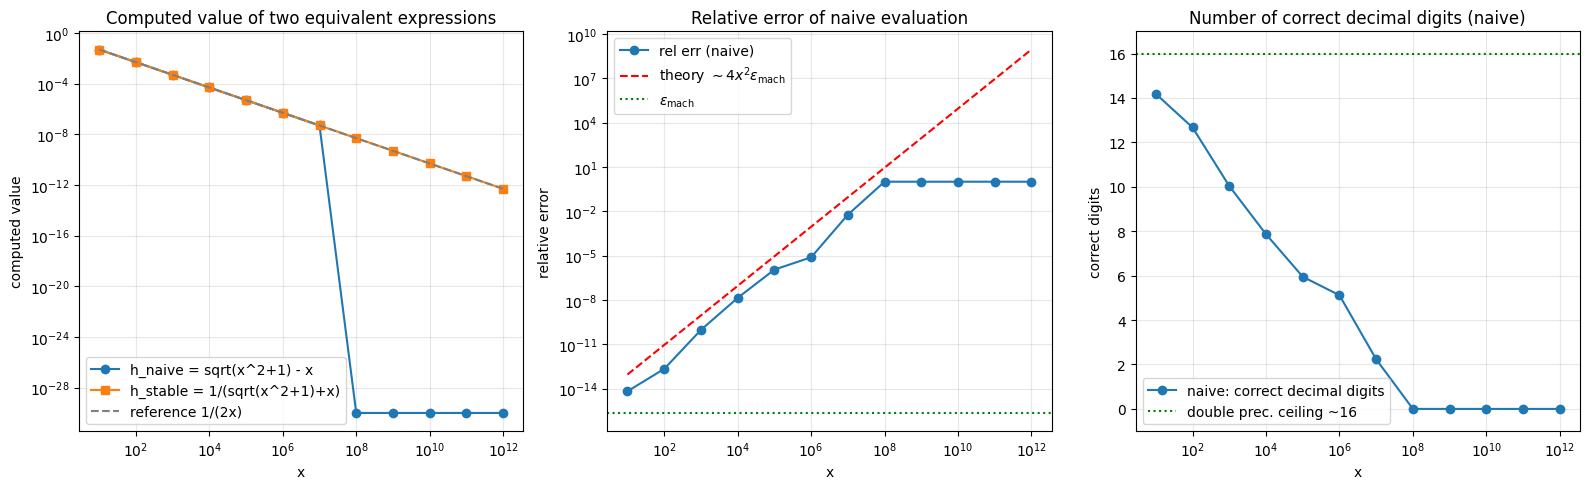

In [3]:
fig, ax = plt.subplots(1, 3, figsize=(16, 5))

# (a) 두 식의 값
ax[0].loglog(x, np.maximum(h_naive,  1e-30), "o-", label="h_naive = sqrt(x^2+1) - x")
ax[0].loglog(x, h_stable, "s-", label="h_stable = 1/(sqrt(x^2+1)+x)")
ax[0].loglog(x, 1.0/(2.0*x), "--", color="gray", label="reference 1/(2x)")
ax[0].set_xlabel("x")
ax[0].set_ylabel("computed value")
ax[0].set_title("Computed value of two equivalent expressions")
ax[0].legend()
ax[0].grid(True, which="both", alpha=0.3)

# (b) 상대오차
ax[1].loglog(x, np.maximum(rel_err_naive, 1e-20), "o-", label="rel err (naive)")
eps = np.finfo(float).eps
# 이론 cancellation 증폭: ~ 4 x^2 * eps
ax[1].loglog(x, 4.0 * x**2 * eps, "--", color="red", label=r"theory $\sim 4 x^2 \varepsilon_{\rm mach}$")
ax[1].axhline(eps, ls=":", color="green", label=r"$\varepsilon_{\rm mach}$")
ax[1].set_xlabel("x")
ax[1].set_ylabel("relative error")
ax[1].set_title("Relative error of naive evaluation")
ax[1].legend()
ax[1].grid(True, which="both", alpha=0.3)

# (c) 정확 자릿수
ax[2].semilogx(x, correct_digits, "o-", label="naive: correct decimal digits")
ax[2].axhline(16, ls=":", color="green", label="double prec. ceiling ~16")
ax[2].set_xlabel("x")
ax[2].set_ylabel("correct digits")
ax[2].set_title("Number of correct decimal digits (naive)")
ax[2].legend()
ax[2].grid(True, which="both", alpha=0.3)
ax[2].set_ylim(-1, 17)

plt.tight_layout()
plt.show()


In [4]:
# 단정도(float32)에서는 더 일찍 무너진다 — 보조 실험
x32 = (10.0 ** np.arange(1, 9)).astype(np.float32)
h_naive32 = np.sqrt(x32*x32 + np.float32(1.0)) - x32
h_stable32 = np.float32(1.0) / (np.sqrt(x32*x32 + np.float32(1.0)) + x32)

df32 = pd.DataFrame({
    "x (float32)": x32,
    "naive (f32)": h_naive32,
    "stable (f32)": h_stable32,
    "rel err (naive, f32)": np.abs(h_naive32.astype(np.float64) - h_stable32.astype(np.float64))
                            / np.abs(h_stable32.astype(np.float64)),
})
df32


,x (float32),naive (f32),stable (f32),"rel err (naive, f32)"
0,1.000000e+01,4.987526e-02,4.987562e-02,7.245086e-06
1,1.000000e+02,4.997253e-03,4.999875e-03,5.243477e-04
2,1.000000e+03,4.882812e-04,4.999998e-04,2.343721e-02
3,1.000000e+04,0.000000e+00,5.000000e-05,1.000000e+00
4,1.000000e+05,0.000000e+00,5.000000e-06,1.000000e+00
5,1.000000e+06,0.000000e+00,5.000000e-07,1.000000e+00
6,1.000000e+07,0.000000e+00,5.000000e-08,1.000000e+00
7,1.000000e+08,0.000000e+00,5.000000e-09,1.000000e+00


## 4. 결과 해석

1. **점근적 동작**: 두 표현 모두 $x$ 가 작을 때는 $1/(2x)$ 와 잘 부합. 안정식은 $x = 10^{12}$ 에서도 부드러운 곡선을 따르고, 점근 전개와의 차이도 $\sim 1/(40 x^5)$ 의 다음 항 크기와 일치.
2. **불안정식의 붕괴**: $x = 10^7 \sim 10^8$ 부터 `naive` 의 상대오차가 $1$ 에 도달 — 즉 *정확 자릿수 0*. 이론치 $\sim 4 x^2 \varepsilon_{\rm mach}$ 와 거의 같은 기울기로 증가한다.
3. **임계점 추정**: $4 x^2 \varepsilon_{\rm mach} = 1 \;\Rightarrow\; x \approx \sqrt{1/(4\varepsilon_{\rm mach})} \approx 3.4 \times 10^7$. 표/그래프 상의 붕괴 시점과 잘 맞는다.
4. **단정도 비교**: float32 에서는 같은 패턴이 $x \sim 10^3$ 부터 무너진다 — $\varepsilon_{\rm mach}^{(32)} \approx 1.19 \times 10^{-7}$.

### 결론
> **유리화는 cancellation을 *분모 쪽으로 옮기는* 가장 강력한 일반 기법이다.**
> 분자에서 사라질 위기였던 자릿수가 분모의 *합* 으로 변환되면서 안전해진다.
> 같은 식을 두 가지로 평가할 때, 부동소수점에서는 *어느 쪽이 cancellation을 만드는가* 만이 중요하다.

### 다음 문제로
문제 12에서는 **자기 함수**를 골라 cancellation 패턴을 직접 시각화한다 — 단순한 $f(x) = e^x - 1$ 의 작은 $x$ 거동에서, Taylor / `expm1` 같은 라이브러리 대안 / 항등식 변형의 효과를 비교한다.
